# Инструменты для анализа и предобработки данных

Цель данной лабораторной работы - вспомнить инструментарий pandas, SQL и matplotlib для проведения анализа и предобработки данных.

С точки зрения машинного обучения в данной работе будет рассмотрен алгоритм kNN, алгоритм кластеризации kMeans, а также некоторые методы снижения размерности.

Датасет, с которым вам предстоит работать, содержит информацию о покупателях в одном из магазинов. Данные разделены на несколько файлов.
<br><br>
**people**

`id`: уникальный идентификатор клиента

`year_birth`: год рождения клиента

`education`: уровень образования клиента

`marital_status`: семейное положение клиента

`income`: годовой доход семьи клиента

`kidhome`: количество детей в доме клиента

`teenhome`: количество подростков в доме клиента

`dt_customer`: дата регистрации клиента в компании

`recency`: количество дней с момента последней покупки клиента

`complain`: 1, если клиент жаловался в последние 2 года, 0 в противном случае
<br><br>
**products**

`id`: уникальный идентификатор клиента

`mntwines`: сумма, потраченная на вино за последние 2 года

`mntfruits`: сумма, потраченная на фрукты за последние 2 года

`mntmeatproducts`: сумма, потраченная на мясные продукты за последние 2 года

`mntfishproducts`: сумма, потраченная на рыбу за последние 2 года

`mntsweetproducts`: сумма, потраченная на сладости за последние 2 года

`mntgoldprods`: сумма, потраченная на золото за последние 2 года
<br><br>
**purchases**

`id`: уникальный идентификатор клиента

`numwebpurchases`: количество покупок через веб-сайт компании

`numcatalogpurchases`: количество покупок с использованием каталога

`numstorepurchases`: количество покупок непосредственно в магазинах

`numwebvisitsmonth`: количество посещений веб-сайта компании в последний месяц

`numdealspurchases`: количество покупок скидочных товаров

In [1]:
!gdown 1LUjAJR6hNs5IAnQscisvM2hUemvYRLWy
!unzip customers.zip

"gdown" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.
"unzip" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


## pandas, sql

Прочитайте данные. Сколько строк и столбцов содержат таблицы? Есть ли в данных пропуски?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

people = pd.read_csv('people.csv', sep=';')
products = pd.read_csv('products.csv', sep='	')
purchases = pd.read_csv('purchases.csv')

for name, table in [('people', people), ('products', products), ('purchases', purchases)]:
    print(f'{name}: {table.shape[0]} строк, {table.shape[1]} столбцов')
    print(table.isna().sum())
    print()


people: 2240 строк, 10 столбцов
id                 0
year_birth         0
education          0
marital_status     0
income            24
kidhome            0
teenhome           0
dt_customer        0
recency            0
complain           0
dtype: int64

products: 2240 строк, 7 столбцов
id                  0
mntwines            0
mntfruits           0
mntmeatproducts     0
mntfishproducts     0
mntsweetproducts    0
mntgoldprods        0
dtype: int64

purchases: 2240 строк, 6 столбцов
id                     0
numdealspurchases      0
numwebpurchases        0
numcatalogpurchases    0
numstorepurchases      0
numwebvisitsmonth      0
dtype: int64



**Вывод:** во всех трёх таблицах по 2240 строк. У `people` — 10 столбцов, у `products` — 7, у `purchases` — 6. Пропуски есть только в `people.income` (24 из 2240 строк, ~1%), в остальных столбцах и таблицах пропусков нет.

Каждое из следующих заданий необходимо выполнить двумя способами - с помощью pandas и с помощью SQL. Не используйте объединение таблиц через join/merge/concat.

In [3]:
import sqlite3

conn = sqlite3.connect(':memory:')  # создание временной базы данных

people.to_sql('people', conn, index=False)
products.to_sql('products', conn, index=False)
purchases.to_sql('purchases', conn, index=False)

query = "SELECT * FROM people LIMIT 5;"
result = pd.read_sql_query(query, conn)
result

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,complain
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,0


### 1

Найдите абсолютную разницу между минимальным доходом клиентов с детьми и максимальным доходом клиентов без детей. Учитывайте только столбец `kidhome`.

In [4]:
min_income_with_kids = people.loc[people['kidhome'] > 0, 'income'].min()
max_income_without_kids = people.loc[people['kidhome'] == 0, 'income'].max()

diff = abs(min_income_with_kids - max_income_without_kids)
diff


np.float64(158356.0)

In [5]:
query = """
SELECT ABS(
    (SELECT MIN(income) FROM people WHERE kidhome > 0) -
    (SELECT MAX(income) FROM people WHERE kidhome = 0)
) AS diff;
"""
result = pd.read_sql_query(query, conn)
result


,diff
0,158356.0


### 2
Посчитайте процентное соотношение клиентов, имеющих PhD или другой уровень образования, среди клиентов, покупающих и не покупающих сладкое. Ответ представьте в виде:

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <style>
        th, td {
            text-align: center;
            padding: 10px;
        }
        th {
            font-weight: bold;
        }
    </style>
</head>
<body>

<table border="1">
  <tr>
    <th></th>
    <th>PhD</th>
    <th>Other</th>
  </tr>
  <tr>
    <th>Sweets</th>
    <td>percentage</td>
    <td>percentage</td>
  </tr>
  <tr>
    <th>No Sweets</th>
    <td>percentage</td>
    <td>percentage</td>
  </tr>
</table>

</body>
</html>

Сумма по строке должна давать единицу.

In [6]:
sweet_ids = products.loc[products['mntsweetproducts'] > 0, 'id']
no_sweet_ids = products.loc[products['mntsweetproducts'] == 0, 'id']

def phd_vs_other(ids):
    edu = people.loc[people['id'].isin(ids), 'education']
    phd_share = (edu == 'PhD').mean()
    return phd_share, 1 - phd_share

sweets_phd, sweets_other = phd_vs_other(sweet_ids)
no_sweets_phd, no_sweets_other = phd_vs_other(no_sweet_ids)

result = pd.DataFrame(
    {'PhD': [sweets_phd, no_sweets_phd], 'Other': [sweets_other, no_sweets_other]},
    index=['Sweets', 'No Sweets'],
)
result


,PhD,Other
Sweets,0.182867,0.817133
No Sweets,0.365155,0.634845


In [ ]:
query = """
SELECT
    CASE WHEN id IN (SELECT id FROM products WHERE mntsweetproducts > 0)
         THEN 'Sweets' ELSE 'No Sweets' END AS group_name,
    AVG(CASE WHEN education = 'PhD' THEN 1.0 ELSE 0.0 END) AS PhD,
    AVG(CASE WHEN education != 'PhD' THEN 1.0 ELSE 0.0 END) AS Other
FROM people
GROUP BY group_name
ORDER BY group_name DESC;
"""
result = pd.read_sql_query(query, conn)
result


## EDA

Изучите графики, которые предлагает построить Google Colab. Какие из них несут смысл, а какие выглядят бесполезными? На основании изученных графиков сформулируйте любую гипотезу по данным и постройте график, который поможет подтвердить или опровергнуть вашу гипотезу. Ваш график должен отличаться от уже представленных!

**people**

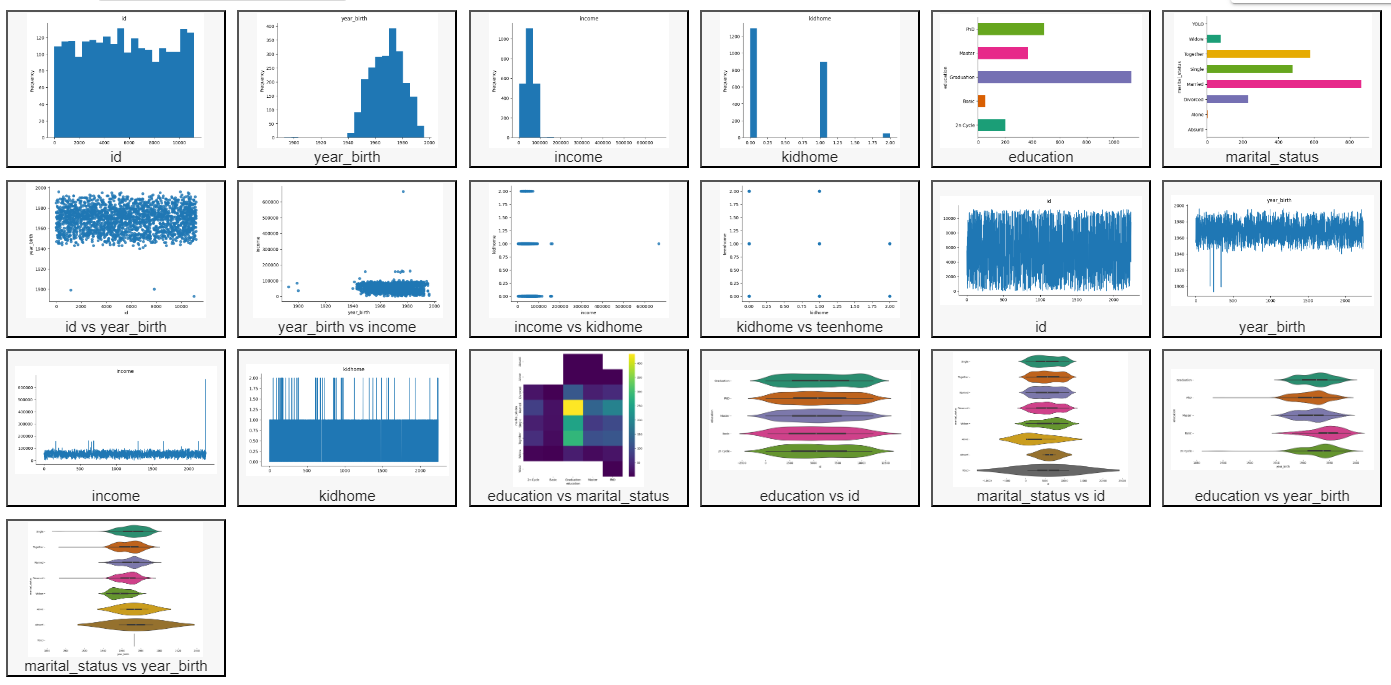

**products**

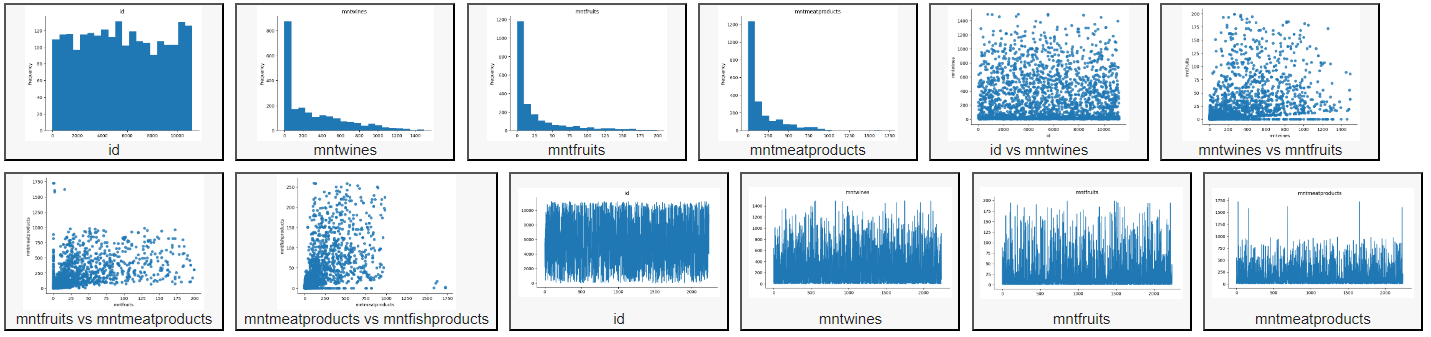

**purchases**

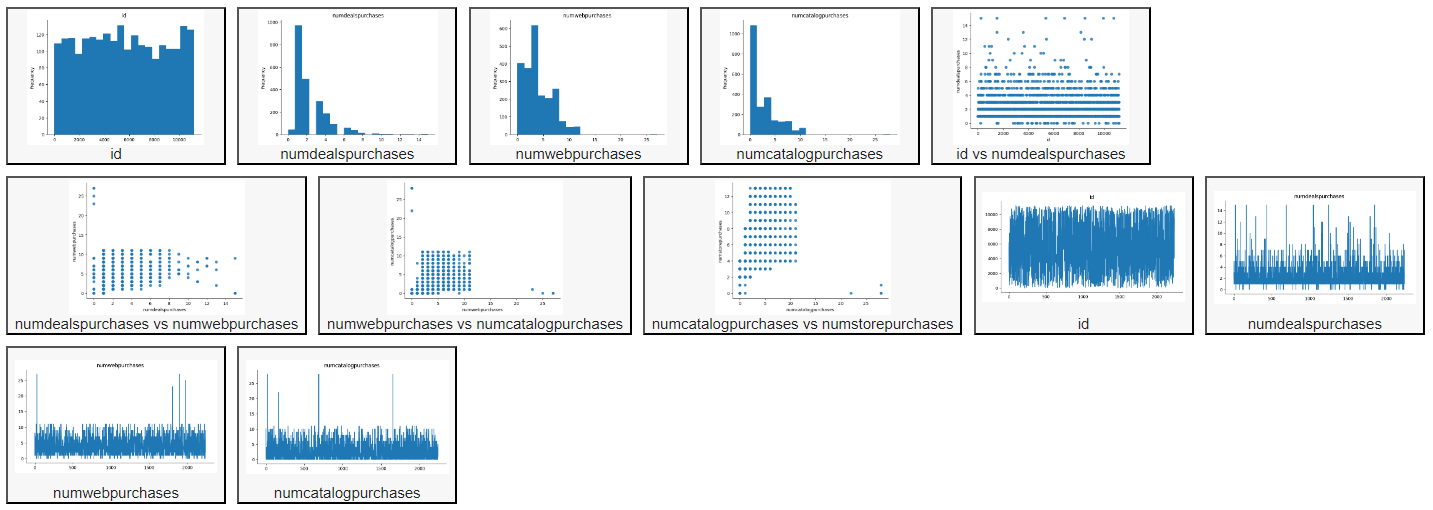

**Вывод:** содержательны гистограммы/бар-чарты по отдельным признакам (`year_birth`, `income`, `kidhome`, `education`, `marital_status`, `mntwines` и т.д.) — по ним видно распределение и выбросы: например, доход ~666 000 и год рождения ~1900 сильно выделяются на фоне остальных. Полезны тепловая карта `education vs marital_status` и violin-графики `... vs year_birth` — показывают, как признаки связаны с возрастом клиента. Бесполезны все графики, где участвует `id` (гистограмма `id`, `id vs ...`, линейные графики `id`/признак по индексу, violin `... vs id`) — `id` это просто идентификатор без смысла, такие графики просто показывают шум. Заодно `marital_status` выдаёт проблему с качеством данных — есть подозрительные категории `Absurd` и `YOLO`.

Гипотеза: чем выше доход клиента, тем больше он тратит на вино (income положительно коррелирует с mntwines).

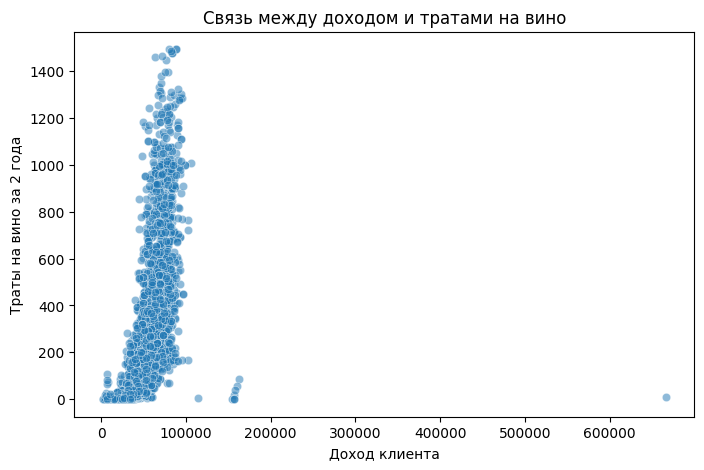

,income,mntwines
income,1.00000,0.57865
mntwines,0.57865,1.00000


In [8]:
merged = pd.merge(people, products, on='id')

plt.figure(figsize=(8, 5))
sns.scatterplot(data=merged, x='income', y='mntwines', alpha=0.5)
plt.xlabel('Доход клиента')
plt.ylabel('Траты на вино за 2 года')
plt.title('Связь между доходом и тратами на вино')
plt.show()

merged[['income', 'mntwines']].corr()


**Вывод:** гипотеза подтверждается — корреляция между `income` и `mntwines` положительная и заметная (r ≈ 0.58). С ростом дохода траты на вино растут, хотя разброс большой. Также виден один клиент-выброс с доходом ≈ 660 000 — его стоит проверить отдельно перед дальнейшим анализом.

## Предобработка данных

Соберём разрозненные таблицы в одну (и порадуемся, что их объём позволяет это сделать). Как мы помним, в данных были пропуски.

In [9]:
df = pd.merge(pd.merge(people, products, on='id'), purchases, on='id')
df.isna().sum()

id                      0
year_birth              0
education               0
marital_status          0
income                 24
kidhome                 0
teenhome                0
dt_customer             0
recency                 0
complain                0
mntwines                0
mntfruits               0
mntmeatproducts         0
mntfishproducts         0
mntsweetproducts        0
mntgoldprods            0
numdealspurchases       0
numwebpurchases         0
numcatalogpurchases     0
numstorepurchases       0
numwebvisitsmonth       0
dtype: int64

Не все алгоритмы машинного обучения умеют работать с пропусками в данных. Есть несколько стратегий для борьбы с пропусками, самая частая - заполнение пропусков модой, медианой или средним. Если пропусков слишком много, то имеет смысл выбросить соответствующую строку или столбец целиком.

Есть и более продвинутые методы, например kNN (K Nearest Neighbours). Суть данного метода заключается в том, что на основании известных признаков для объекта находятся "соседи", располагающиеся как можно ближе к исходному объекту в пространстве. Затем по этим объектам вычисляется значение недостающего признака.

Возникает два вопроса:

1. Каким образом представить объекты в пространстве?
2. Как считать расстояние между ними?

Ответ на оба — зависит от задачи. Объект обычно проще всего представить как вектор признаков. Для подсчета расстояния используются, например:
- евклидово расстояние и его общий случай (расстояние минковского);
- косинусное расстояние;
- манхэттенское расстояние
- расстояние Чебышёва;
- какое угодно, придуманное вами.

Реализуем kNN для восстановления пропущенных значений `income`. Будем считать евклидово расстояние между векторами. Сначала превратим каждую строку в числовой вектор. Для этого выполним следующие шаги:

* удалим столбец `id`

* проведём one-hot кодирование столбцов `education` и `marital_status`

* проведём нормировку (min-max scaling) столбца `dt_customer`

* проведём нормализацию (z-scaling) полученных векторов, потому что евклидово расстояние чувствительно к размерности признаков

Подумайте, почему именно такие преобразования являются необходимыми.

In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler


df = df.drop(columns='id')
df = pd.get_dummies(df, columns=['education', 'marital_status'])

df['dt_customer'] = pd.to_datetime(df['dt_customer'], dayfirst=True).astype('int64')
df['dt_customer'] = MinMaxScaler().fit_transform(df[['dt_customer']])

# income остаётся "как есть" (не масштабируем) - в нём пропуски, которые предстоит заполнить
feature_cols = [c for c in df.columns if c != 'income']
df[feature_cols] = StandardScaler().fit_transform(df[feature_cols])


Допишите реализацию kNN.

In [11]:
import numpy as np
from scipy.spatial import distance


class CustomKNeighborsRegressor:
    def __init__(self, n_neighbors=3):
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = y

    def kneighbors(self, X_test):
        X_test = np.asarray(X_test, dtype=float)
        dist_matrix = distance.cdist(X_test, self.X_train, metric='euclidean')
        indices = np.argsort(dist_matrix, axis=1)[:, :self.n_neighbors]
        distances = np.take_along_axis(dist_matrix, indices, axis=1)
        return distances, indices


knn = CustomKNeighborsRegressor(n_neighbors=3)
knn.fit(df.dropna().drop(columns='income'), df.dropna())
distances, indices = knn.kneighbors(df[df['income'].isna()].drop(columns='income'))


Если вы всё сделали правильно, то результаты должны совпасть с решением "из коробки", порядок возвращаемых соседей можно не учитывать.

In [12]:
from sklearn.neighbors import KNeighborsRegressor


knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(df.dropna().drop(columns='income'), df.dropna())
distances, indices = knn.kneighbors(df[df['income'].isna()].drop(columns='income'))

Заполните пропуски в `income` средним значением по 3 ближайшим соседям.

In [13]:
missing_idx = df[df['income'].isna()].index
train_incomes = df.dropna()['income'].to_numpy()
neighbor_incomes = train_incomes[indices]
df.loc[missing_idx, 'income'] = neighbor_incomes.mean(axis=1)


In [14]:
df['income'] = StandardScaler().fit_transform(df[['income']])

## Кластеризация. Методы снижения размерности

In [15]:
%%capture
!pip install umap-learn

Раз уж мы заговорили про поиск похожих между собой объектов, обсудим также кластеризацию.

[Кластеризация](https://ru.wikipedia.org/wiki/%D0%9A%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%BD%D1%8B%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7) - это один из видов задач обучения без учителя. Она заключается в разбиении всех объектов на группы похожих между собой объектов и сильно отличающихся от всех остальных. Так как строгого понятия похожести объектов нет, то алгоритмов кластеризации много, а результаты их работы могут сильно зависеть от качества входных данных и подобранных гиперпараметров.

Обсудим один из самых популярных методов кластеризации - [kMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).

Идея метода заключается в том, что на каждой итерации пересчитывается центр масс (центроид) для каждого кластера, полученного на предыдущем шаге, затем объекты снова разбиваются на кластеры согласно тому, какой из новых центроидов находится ближе.
Более формально, алгоритм принимает на вход выборку $X_1, \dots, X_N$ и параметр $k$, указывающий необходимое число кластеров. Выходом алгоритма является набор из $k$ центроидов $\{\mu_1, \dots, \mu_k\}$, с помощью которых кластеризация осуществляется путём отнесения каждого объекту к ближайшему центроиду. Все точки внутри одного кластера ближе к центроиду этого кластера, чем к центроиду любого другого кластера.
Метод может быть сформулирован как задача оптимизации, а именно, минимизации суммарного квадратичного отклонения точек кластеров от центров этих кластеров по центроидам и кластерам: $$\sum_{i=1}^k \sum_{X_n \in C_i} ||X_n - \mu_i||^2 \rightarrow \min, \text{где $C_i$ - это $i$-ый кластер, $\mu_i$ - это центр масс кластера $C_i$.}$$
Решение такой задачи оптимизации является NP-трудной задачей, однако существует простой итеративный алгоритм, позволяющий найти локальный минимум указанного функционала. Алгоритм представляет собой последовательное чередование двух шагов до сходимости.
Предположим, что как-то (например, случайно) выбраны начальные положения центроидов $\mu_1, \dots, \mu_k$.

1. Этап кластеризации. На данном этапе происходит кластеризация выборки, как было описано выше: каждый объект относится к кластеру ближайшего к нему центроида. Формально, $$C_i = \{X_n : ||X_n - \mu_i|| \leq ||X_n - \mu_j||, \text{ для всех $j \in \{1, \dots, k\}$}\}.$$

2. Этап обновления центроидов. На данном этапе центроиды пересчитываются, как центры масс только что построенных кластеров. Формально, $$\mu_i = \frac{1}{|C_i|}\sum_{X_n \in C_i} X_n.$$

Этот процесс продолжается, пока центроиды и кластеризация продолжают изменяться. Алгоритм гарантированно сходится, однако не гарантируется достижение глобального минимума, а только одного из локальных минимумов. Другим недостатком алгоритма является то, что итоговая кластеризация зависит от выбора исходных центров кластеров. На практике алгоритм запускается несколько раз из различных начальных приближений, а полученные результаты некоторым образом усредняются. Стоит также отметить, что число кластеров необходимо знать заранее. Существуют различные эвристики, позволяющие выбирать в некотором смысле оптимальное число кластеров.

_определение взято из материалов курса [ODS](https://habrahabr.ru/company/ods/)_


Посмотрим, что будет давать реализация алгоритма "из коробки" на наших данных. Возьмем только данные из таблицы продуктов.


In [16]:
X = StandardScaler().fit_transform(products.drop(columns='id'))

Сначала нужно определиться с количеством кластеров. Для этого можно воспользоваться "методом локтя" - мы рeшаем задачу кластеризации несколько раз с разным количеством кластеров и выбираем то минимальное количество кластеров, после которого существенного улучшения не происходит. Ориентироваться будем на две метрики - kMeans.inertia_ и Silhouette Score.

**kMeans.inertia_** отражает сумму расстояний от каждой точки до центра ее кластера, возведенных в квадрат. Это значение также известно как сумма внутрикластерных квадратов (Within-Cluster Sum of Squares, WCSS). Математически инерция выражается следующим образом:

$ Inertia = \sum_{i=0}^{n}(min_{\mu_j \in C}(||x_i - \mu_j||^2)) $

Где $x_i$ - это i-й элемент выборки, $\mu_j$ - это центроид кластера $C$, а $||x_i - \mu_j||$ обозначает Евклидово расстояние между точкой $x_i$ и центроидом $\mu_j$. Инерция показывает, насколько плотно группируются объекты внутри кластеров: чем меньше значение инерции, тем ближе объекты находятся к центроидам своих кластеров.

**Silhouette Score** (Силуэт) рассчитывается как разница между средним расстоянием до объектов других кластеров (b) и средним расстоянием до объектов в том же кластере (a), деленная на максимальное из этих значений:

$s = \frac{b - a}{max(a, b)}$

Где $a$ - это среднее расстояние от объекта до других объектов в том же кластере, а $b$ - это минимальное среднее расстояние от объекта до объектов в других кластерах. Значение силуэта лежит в диапазоне от -1 до 1, где высокий положительный счет указывает на то, что объект хорошо соответствует своему кластеру и плохо соответствует соседним кластерам. Обычно, чем выше средний силуэт для всех объектов, тем лучше структурированы кластеры.

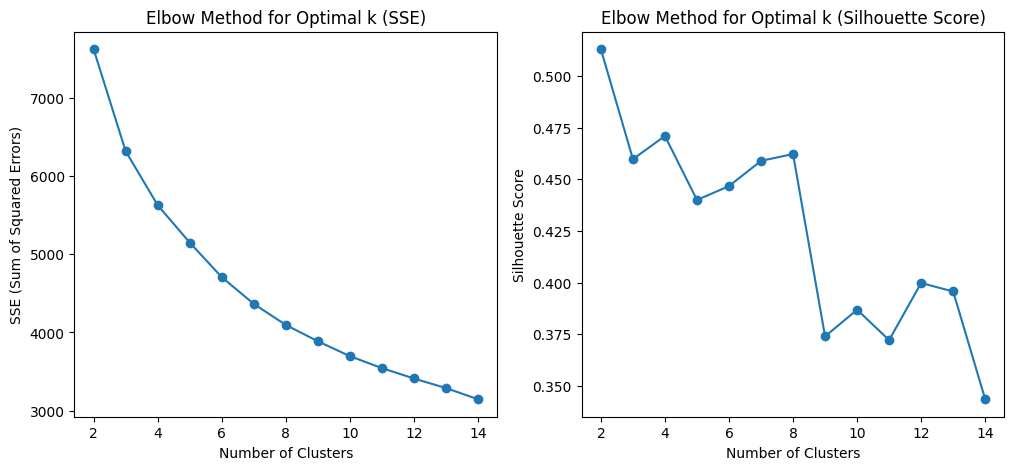

In [17]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score


xaxs = list(range(2, 15))
kmeans_kwargs = {
    "init": "k-means++",
    "n_init": 10,
    "random_state": 42,
    "algorithm": "lloyd"
}

silhouette_scores = []
sse = []

for k in xaxs:
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

    silhouette_avg = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(12, 5))

# SSE
plt.subplot(1, 2, 1)
plt.plot(xaxs, sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE (Sum of Squared Errors)')
plt.title('Elbow Method for Optimal k (SSE)')

# Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(xaxs, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Elbow Method for Optimal k (Silhouette Score)')

plt.show()

4 кластера выглядит хорошо. 8 тоже.

In [18]:
kmeans = KMeans(n_clusters=4, **kmeans_kwargs)
kmeans.fit(X)
cluster_labels = kmeans.labels_

Посмотрим на то, что получается. 6-мерный вектор будет проблематично отобразить на плоскости, поэтому прибегнем к снижению размерности - переходом в меньшее по количеству измерений признаковое пространство. Рассмотрим три подхода, имеющих реализацию "из коробки" - PCA, t-SNE, UMAP.

**PCA (метод главных компонент)** - это линейный алгоритм, который используется для уменьшения размерности данных путем проекции их на пространство меньшей размерности, сохраняя при этом максимальное количество информации в данных. Это достигается путем определения новых осей (главных компонент), которые направлены в сторону максимальной дисперсии данных. Первая главная компонента имеет наибольшую дисперсию, вторая - максимальную дисперсию среди оставшихся компонент и так далее. Для выбора количества главных компонент часто используют критерий, основанный на объясненной дисперсии, то есть на той доле общей дисперсии, которую объясняют выбранные компоненты.

**t-SNE (Стохастическое вложение соседей с t-распределением)** - это нелинейный алгоритм, который работает на основе вероятностных распределений: в многомерном пространстве данные моделируются так, что похожие объекты имеют высокую вероятность быть "соседями", в то время как непохожие объекты - низкую. Эти вероятности затем используются для определения расположения объектов в пространстве уменьшенной размерности таким образом, чтобы структура данных оставалась похожей. Чем-то напоминает kNN.


**UMAP (Uniform Manifold Approximation and Projection)** - это современный алгоритм уменьшения размерности, который можно считать конкурентом t-SNE. Он также основан на концепции многомерного многообразия, но использует другой математический подход, основанный на топологии. UMAP стремится сохранить глобальную структуру данных, в отличие от t-SNE, который фокусируется больше на локальной.

[Немного красивых картинок](https://habr.com/ru/companies/newprolab/articles/350584/)

c:\Users\raven\Projects\tutor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\raven\Projects\tutor\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


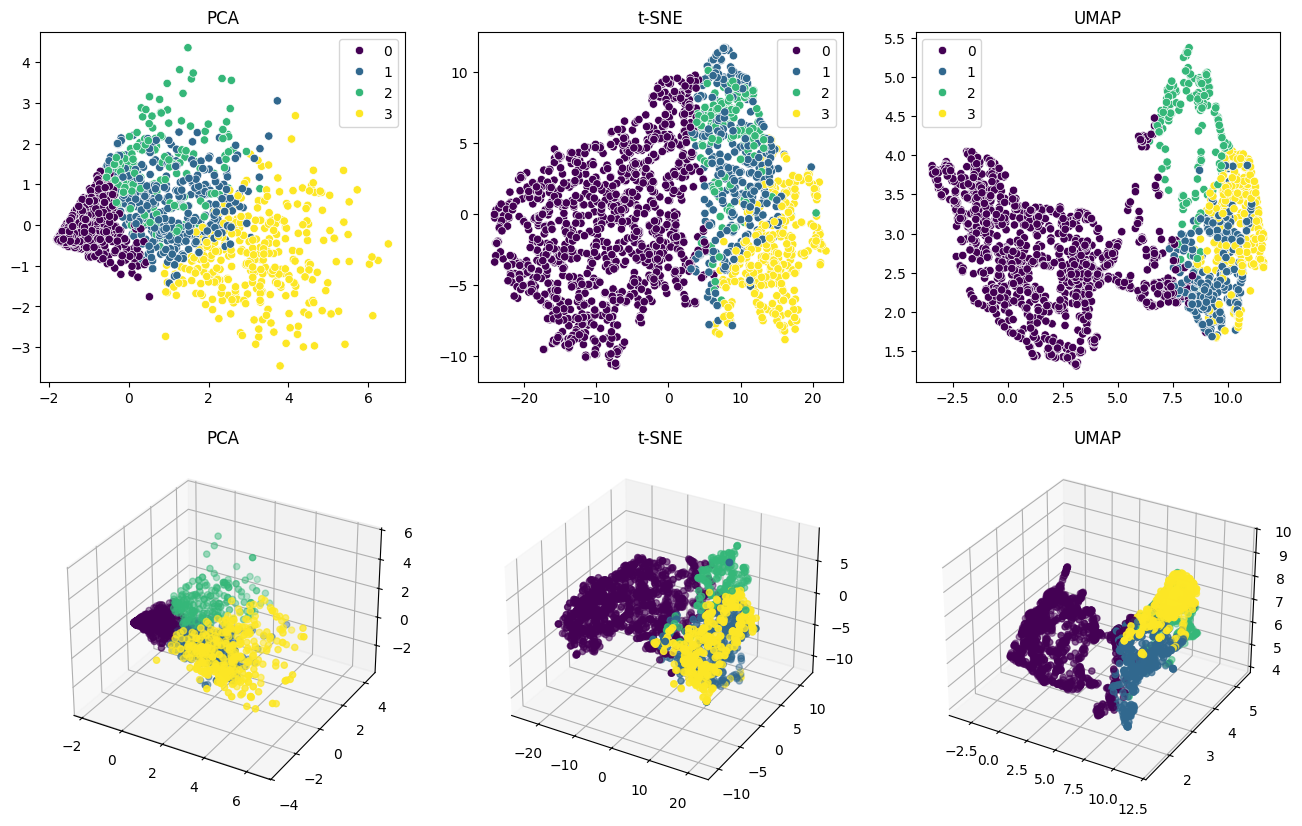

In [19]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from mpl_toolkits.mplot3d import Axes3D


pca = PCA(n_components=3)
tsne = TSNE(n_components=3, random_state=42)
umap = UMAP(n_components=3, random_state=42)

pca_result = pca.fit_transform(X)
tsne_result = tsne.fit_transform(X)
umap_result = umap.fit_transform(X)

plt.figure(figsize=(16, 10))

# 2D Plots
plt.subplot(2, 3, 1)
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=cluster_labels, palette='viridis')
plt.title('PCA')

plt.subplot(2, 3, 2)
sns.scatterplot(x=tsne_result[:,0], y=tsne_result[:,1], hue=cluster_labels, palette='viridis')
plt.title('t-SNE')

plt.subplot(2, 3, 3)
sns.scatterplot(x=umap_result[:,0], y=umap_result[:,1], hue=cluster_labels, palette='viridis')
plt.title('UMAP')

# 3D Plots
ax1 = plt.subplot(2, 3, 4, projection='3d')
ax1.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2], c=cluster_labels, cmap='viridis')
ax1.set_title('PCA')

ax2 = plt.subplot(2, 3, 5, projection='3d')
ax2.scatter(tsne_result[:, 0], tsne_result[:, 1], tsne_result[:, 2], c=cluster_labels, cmap='viridis')
ax2.set_title('t-SNE')

ax3 = plt.subplot(2, 3, 6, projection='3d')
ax3.scatter(umap_result[:, 0], umap_result[:, 1], umap_result[:, 2], c=cluster_labels, cmap='viridis')
ax3.set_title('UMAP')

plt.show()

**Вывод:** во всех трёх проекциях кластер 0 (фиолетовый) выделяется чётко и отдельно от остальных, а кластеры 1, 2, 3 частично перекрываются между собой. PCA как линейный метод разделяет их хуже всего — границы между кластерами 1-3 размыты. t-SNE и UMAP (нелинейные методы) показывают более чёткое разделение, потому что лучше сохраняют локальную структуру соседей, а не только направления максимальной дисперсии.

Попробуйте проинтерпретировать получающиеся результаты.

In [20]:
products['cluster_labels'] = cluster_labels
products['cluster_labels'].value_counts()

cluster_labels
0    1297
1     392
3     347
2     204
Name: count, dtype: int64

In [21]:
cluster_means = products.drop(columns='id').groupby('cluster_labels').mean()
cluster_means.style.background_gradient(cmap='Blues', axis=0)  # можно ли сказать, что у нас есть кластер любителей вина?..

,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods
cluster_labels,,,,,,
0,96.339244,6.353123,35.407864,8.926754,6.353123,17.320740
1,717.056122,35.826531,366.737245,53.158163,35.084184,39.551020
2,472.176471,25.730392,169.426471,32.328431,25.029412,143.426471
3,514.276657,90.443804,431.469741,129.815562,96.605187,90.435159


**Вывод:** да, кластер любителей вина есть — это кластер 1: траты на вино там ≈717 (в 5-7 раз выше, чем в кластере 0, и заметно выше кластеров 2-3), при этом по остальным категориям кластер 1 не всегда лидирует. Кластер 3, для сравнения, тратит больше всего на мясо/рыбу/сладости/фрукты — это скорее кластер "больших чеков в целом", а не специфически вина. Кластер 0 — самый крупный (1297 клиентов) и самый экономный по всем категориям.

### Задание

В предыдущем пункте работы мы применили готовый код для кластеризации, чтобы увидеть, как она работает. Теперь ваша задача - написать код для реализации алгоритма kMeans самостоятельно (речь, конечно, идет о намного менее, нежели версия "из коробки", оптимизированной версии алгоритма).

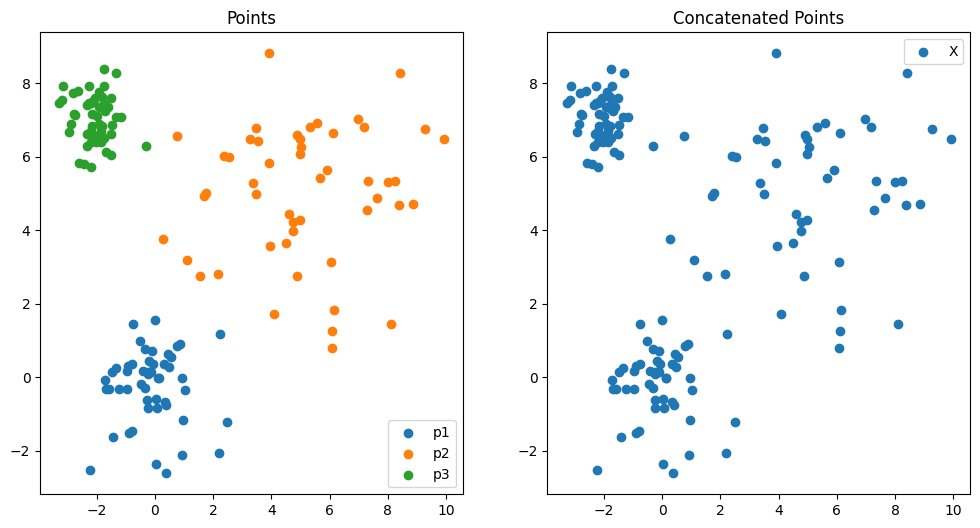

In [22]:
import numpy as np
import matplotlib.pyplot as plt


# игрушечные данные
p1 = np.random.normal(loc=0, scale=1, size=(50,2))
p2 = np.random.normal(loc=5, scale=2, size=(50,2))
p3 = np.random.normal(loc=3, scale=0.6, size=(50,2)) - np.array([5, -4])
X = np.concatenate((p1, p2, p3))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].scatter(p1[:, 0], p1[:, 1], label='p1')
axs[0].scatter(p2[:, 0], p2[:, 1], label='p2')
axs[0].scatter(p3[:, 0], p3[:, 1], label='p3')
axs[0].set_title('Points')
axs[0].legend()

axs[1].scatter(X[:, 0], X[:, 1], label='X')
axs[1].set_title('Concatenated Points')
axs[1].legend()

plt.show()

### 1
Напишите функцию, которая рассчитывает расстояния от центров кластеров до каждой точки и возвращает, к какому кластеру принадлежит каждая точка.

In [23]:
import scipy


def kmeans_predict(X, clusters):
    distances = scipy.spatial.distance.cdist(X, clusters)
    labels = np.argmin(distances, axis=1)
    return labels


Посмотрим, что получается.

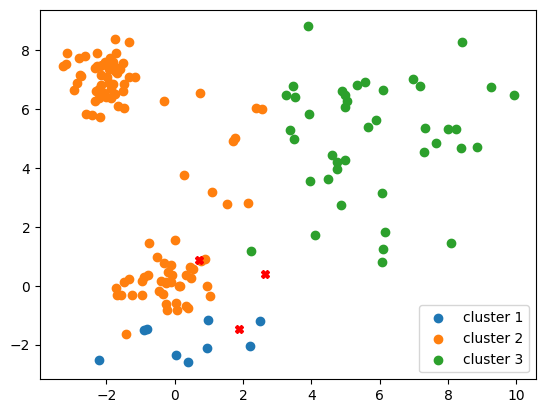

In [24]:
# случайные координаты для центров кластеров
centroids = np.random.normal(loc=0.0, scale=2., size=6).reshape((3, 2))

labels = kmeans_predict(X, centroids)

plt.scatter(X[labels == 0, 0], X[labels == 0, 1], label='cluster 1')
plt.scatter(X[labels == 1, 0], X[labels == 1, 1], label='cluster 2')
plt.scatter(X[labels == 2, 0], X[labels == 2, 1], label='cluster 3')
plt.plot(centroids[:, 0], centroids[:, 1], 'rX')
plt.legend()
plt.show()

Центроиды здесь взяты случайно и почти не совпадают с реальными центрами данных, поэтому разбиение на кластеры пока случайное и несбалансированное — почти все точки уходят в один кластер. Дальше научимся центроиды обновлять.

### 2
Напишите код для обновления центров кластеров. Запоминайте центры кластеров для дальнейшей визуализации.

In [25]:
centroids = np.random.normal(loc=0.0, scale=2., size=6).reshape((3, 2))
k = len(centroids)
centroids_history = [centroids]  # история центров кластеров

iters = 7  # количество шагов итерации обновления центров кластеров

for i in range(iters):
    labels = kmeans_predict(X, centroids)
    centroids = np.array([
        X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j]
        for j in range(k)
    ])
    centroids_history.append(centroids)


Посмотрим на результат.

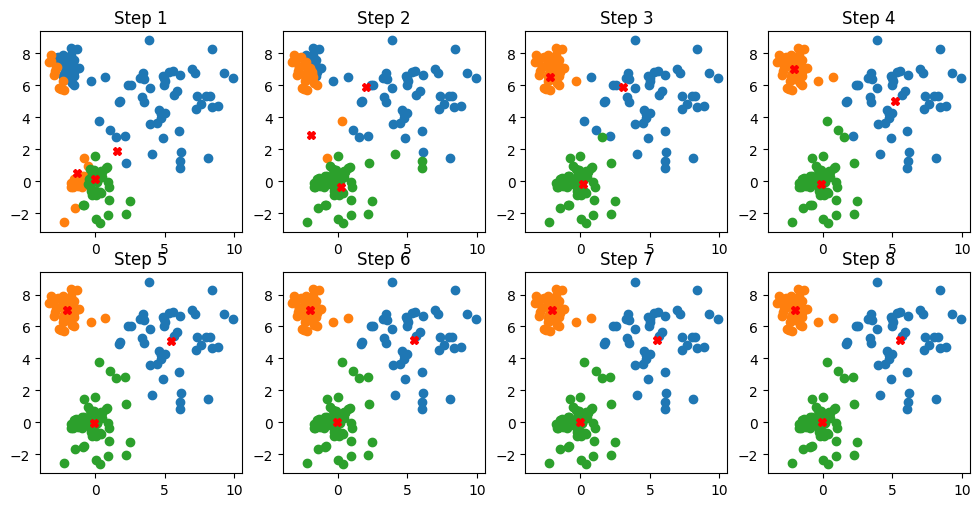

In [26]:
plt.figure(figsize=(12, 12))

for i in range(iters + 1):
    labels = kmeans_predict(X, centroids_history[i])
    plt.subplot((iters + 1) // 2, (iters + 1) // 2, i + 1)
    plt.scatter(X[labels == 0, 0], X[labels == 0, 1], label='cluster 1')
    plt.scatter(X[labels == 1, 0], X[labels == 1, 1], label='cluster 2')
    plt.scatter(X[labels == 2, 0], X[labels == 2, 1], label='cluster 3')
    plt.plot(centroids_history[i][:, 0], centroids_history[i][:, 1], 'rX')
    # plt.legend()
    plt.title('Step {:}'.format(i + 1))

**Вывод:** алгоритм сходится быстро — уже к шагу 3 кластеры практически совпадают с итоговыми, дальше центроиды почти не двигаются. Небольшие колебания на границе синего и оранжевого кластеров видны ещё на шагах 3-5, к шагу 6 разбиение стабилизируется.

### 3

Напишите функцию обучения kMeans. Параметры:

* k - кол-во кластеров,
* max_iter - через сколько итераций нужно остановиться,
* tol - если сумма расстояний между прошлыми центрами кластеров и новыми центрами меньше tol (для всех кластеров!), то остановиться,
* low и high - это минимально и максимально значение, которое могут принимать точки центров кластеров при генерации.



Начните с генерации центров кластеров с помощью np.random.uniform. Затем на каждой итерации нужно сделать следующее:
* определить, к какому кластеру относится каждая точка,
* по точкам в кластере пересчитать центр кластера, если точек в кластере нет - сгенерировать новый случайный центр,
* посчитать loss как сумму расстояний (euclidean) между кластерами, полученными на прошлой итерации, и новыми кластерами.

In [27]:
import numpy as np
from scipy.spatial.distance import cdist


def kmeans_fit_predict(x, k=8, max_iter=100, tol=0.001, low=0.0, high=1.0, print_progress=False):
    n_features = x.shape[1]
    clusters = np.random.uniform(low=low, high=high, size=(k, n_features))
    loss_history = []

    for i in range(max_iter):
        labels = kmeans_predict(x, clusters)

        new_clusters = np.empty_like(clusters)
        for j in range(k):
            mask = labels == j
            if np.any(mask):
                new_clusters[j] = x[mask].mean(axis=0)
            else:
                new_clusters[j] = np.random.uniform(low=low, high=high, size=n_features)

        movements = np.linalg.norm(new_clusters - clusters, axis=1)
        loss = movements.sum()
        loss_history.append(loss)

        if print_progress:
            print(f'Iteration {i}: loss={loss:.6f}')

        clusters = new_clusters
        if np.all(movements < tol):
            break

    labels = kmeans_predict(x, clusters)
    return clusters, labels, loss_history


Проверим работу функции.

In [28]:
clusters, labels, loss_history = kmeans_fit_predict(X, k=3, low=0.0, high=np.max(X), print_progress=True)

Iteration 0: loss=11.194837
Iteration 1: loss=4.295525
Iteration 2: loss=4.025740
Iteration 3: loss=4.198884
Iteration 4: loss=0.749143
Iteration 5: loss=0.310219
Iteration 6: loss=0.000000


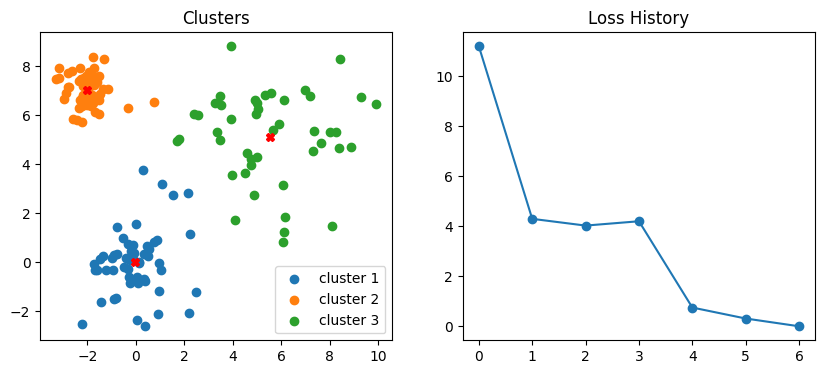

In [29]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[labels == 0, 0], X[labels == 0, 1], label='cluster 1')
plt.scatter(X[labels == 1, 0], X[labels == 1, 1], label='cluster 2')
plt.scatter(X[labels == 2, 0], X[labels == 2, 1], label='cluster 3')
plt.plot(clusters[:, 0], clusters[:, 1], 'rX')
plt.title('Clusters')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss_history, marker='o')
plt.title('Loss History')

plt.show()

**Вывод:** реализация сходится за 7 итераций (loss доходит до 0), кластеры на итоговом графике совпадают с тремя исходными группами `p1`, `p2`, `p3` из первой ячейки этого раздела. Loss убывает немонотонно (небольшой рост между итерациями 2 и 3) — это нормально: сумма смещений центроидов не обязана убывать монотонно на каждом шаге, даже когда алгоритм в целом сходится.